# Setting up

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

mkdir -p failed for path /gpfs/home/yb2612/.config/matplotlib: [Errno 13] Permission denied: '/gpfs/home/yb2612/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-bdbp5set because there was an issue with the default path (/gpfs/home/yb2612/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [32]:
markers = ["CD31", "E-cadherin", "CD68", "CD163", "MPO", "CD20", "CD3e", "CD8", "Granzyme B", "TOX", "CD4", "FOXP3", "TIM3", "CD45RO"]
# samples = ["10103", "34933", "28873"]

def prep_imaging_data(raw_means_csv, metadata_csv, markers, sample_name):
    # load raw biomarker means, filter to markers of interest
    raw_means = pd.read_csv(raw_means_csv)
    print("no of cells:", raw_means.shape[0])
    raw_means_filtered = raw_means[markers]

    # load metadata, filter to abs x, y
    metadata = pd.read_csv(metadata_csv)
    metadata.drop(columns=["absolute_x","absolute_y"], inplace=True)
    metadata["absolute_x"] = metadata["centroid_x"] + metadata["tile_h"]  # FIXED COORDS
    metadata["absolute_y"] = metadata["centroid_y"] + metadata["tile_w"]  # FIXED COORDS
    
    metadata_xy = metadata[["absolute_x", "absolute_y"]].rename(columns={"absolute_x": "X", "absolute_y": "Y"})
    
    # join xy, raw means
    imaging_data = metadata_xy.join(raw_means_filtered)
    imaging_data.to_csv(f"/gpfs/data/proteomics/home/yb2612/data/celesta/cervical/imaging_data_{sample_name}.csv", index=False)

    return imaging_data

In [34]:
data_dir = "/gpfs/data/proteomics/home/yb2612/data/cervical_samples"
os.chdir(data_dir)

for folder in os.listdir():
    folder_path = os.path.join(data_dir, folder)
    if os.path.isdir(folder_path):
        # folder name is like 20250225-Jharna-02433-A1_Scan1.er
        try:
            sample_id = folder.split("-")[2]  # get string after 2nd split
            print(f"Sample ID: {sample_id}")
            
            raw_means_csv = os.path.join(folder_path, "raw_biomarker_means.csv")
            metadata_csv = os.path.join(folder_path, f"{folder}_metadata.csv")

            # Optional: check if files exist
            if os.path.exists(raw_means_csv):
                print(f"Found: {raw_means_csv}")
            else:
                print(f"Missing: {raw_means_csv}")
            
            if os.path.exists(metadata_csv):
                print(f"Found: {metadata_csv}")
            else:
                print(f"Missing: {metadata_csv}")
                
        except IndexError:
            print(f"Could not extract sample ID from folder name: {folder}")

        try:
            imaging_data = prep_imaging_data(raw_means_csv, metadata_csv, markers, f"{sample_id}_raw")
            print("saved imaging_data csv")
            
        except:
            print("could not make imaging_data")

Sample ID: 04738
Found: /gpfs/data/proteomics/home/yb2612/data/cervical_samples/20250318-Jharna-04738-A1_Scan1.er/raw_biomarker_means.csv
Found: /gpfs/data/proteomics/home/yb2612/data/cervical_samples/20250318-Jharna-04738-A1_Scan1.er/20250318-Jharna-04738-A1_Scan1.er_metadata.csv
no of cells: 402830
saved imaging_data csv
Sample ID: 09002
Found: /gpfs/data/proteomics/home/yb2612/data/cervical_samples/20250305-Jharna-09002-A1_Scan1.er/raw_biomarker_means.csv
Found: /gpfs/data/proteomics/home/yb2612/data/cervical_samples/20250305-Jharna-09002-A1_Scan1.er/20250305-Jharna-09002-A1_Scan1.er_metadata.csv
no of cells: 194345
saved imaging_data csv
Sample ID: 07611
Found: /gpfs/data/proteomics/home/yb2612/data/cervical_samples/20250225-Jharna-07611-A3_Scan1.er/raw_biomarker_means.csv
Found: /gpfs/data/proteomics/home/yb2612/data/cervical_samples/20250225-Jharna-07611-A3_Scan1.er/20250225-Jharna-07611-A3_Scan1.er_metadata.csv
no of cells: 1368196
saved imaging_data csv
Sample ID: 34933
Found: 

In [35]:
# display sample df
sample = pd.read_csv("/gpfs/data/proteomics/home/yb2612/data/celesta/cervical/imaging_data_10103_raw.csv")
sample

,X,Y,CD31,E-cadherin,CD68,CD163,MPO,CD20,CD3e,CD8,Granzyme B,TOX,CD4,FOXP3,TIM3,CD45RO
0,2826.105263,16642.000000,2.350877,0.052632,129.122803,0.000000,9.350877,7.929824,93.842102,0.000000,0.000000,0.000000,577.824585,25.052631,34.491226,83.245613
1,2843.611111,16644.675214,10.448718,4.072649,274.363251,0.008547,19.846153,30.602564,149.252136,0.547009,3.196581,9.521367,1901.217896,182.970093,46.286324,225.782059
2,2862.848837,16642.116279,20.348837,2.744186,201.023254,0.000000,35.837208,18.976744,106.651161,0.000000,1.395349,3.220930,890.465088,79.046509,111.046509,110.267441
3,2927.000000,16641.142857,4.678571,92.750000,173.964279,0.000000,463.892853,5.821429,67.000000,5.535714,6.964286,3.035714,474.214294,74.571426,4.500000,68.535713
4,2896.200000,16642.676923,5.169231,0.415385,303.815399,0.000000,8.153846,6.030769,62.061539,0.000000,0.015385,1.923077,804.200012,41.830769,395.123077,65.430771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16627,13104.167763,3310.319079,13.638158,49.486843,100.144737,0.417763,85.789474,63.815788,76.151314,21.381578,4.654605,16.055922,315.717102,124.180923,653.207214,77.835526
16628,13065.238372,3311.761628,5.877907,2.081395,6.069767,0.000000,19.965117,1.936046,14.453488,0.000000,0.087209,0.302326,10.325582,3.168605,0.139535,7.308139
16629,13171.969388,3314.321429,12.576530,805.515320,101.704079,0.214286,136.918365,40.387756,115.250000,4.688776,7.250000,47.025509,505.341827,199.045914,30.433674,95.897957
16630,13184.673981,3316.642633,5.250784,158.300934,52.219437,0.382445,43.257053,32.623825,50.304073,1.266458,5.526646,17.084639,127.909088,82.652039,15.159875,51.739811


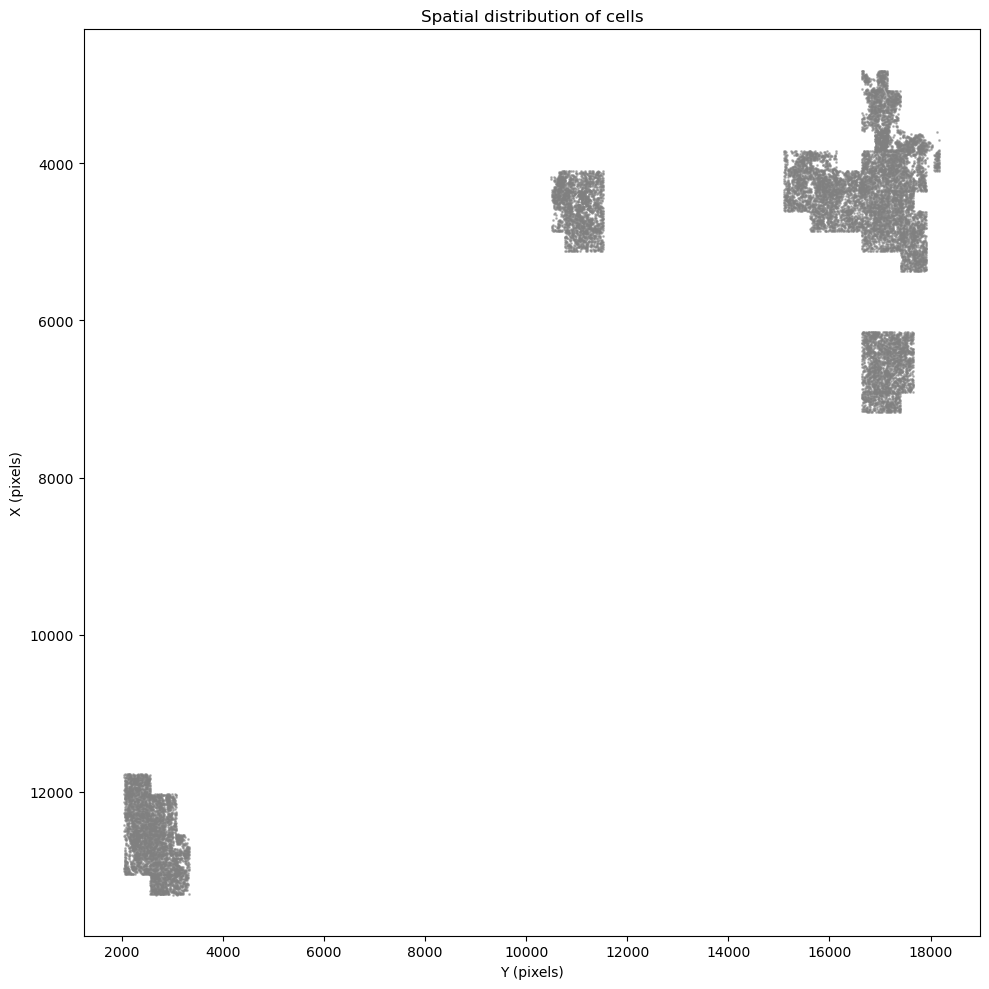

In [37]:
# FIXED COORDS
plt.figure(figsize=(10, 10))
plt.scatter(sample['Y'], sample['X'], s=1, alpha=0.5, c='gray')  # small dots, slightly transparent
plt.gca().invert_yaxis()  # optional: invert Y-axis to match image coordinate system
plt.xlabel("Y (pixels)")
plt.ylabel("X (pixels)")
plt.title("Spatial distribution of cells")
plt.tight_layout()
plt.show()

# Extracting manual cell types

In [6]:
# 10103
# no srt
metadata = pd.read_csv("/gpfs/home/yb2612/yb2612_fenyo/data/cervical_samples/20250225-Jharna-10103-A1_Scan1.er/20250225-Jharna-10103-A1_Scan1.er_prelim_cell_type_metadata.csv")
metadata_fixed = metadata[["barcodes","prelim_cell_type.prelim_cell_type"]].copy()
metadata_fixed.rename(columns={'prelim_cell_type.prelim_cell_type':'manual_cell_type'}, inplace=True)
metadata_fixed.to_csv("/gpfs/home/yb2612/yb2612_fenyo/data/celesta/cervical/manual_cell_type_10103.csv", index=False)

# srt
metadata = pd.read_csv("/gpfs/home/yb2612/yb2612_fenyo/data/cervical_samples/20250225-Jharna-10103-A1_Scan1.er/20250225-Jharna-10103-A1_Scan1.er_prelim_cell_type_srt_metadata.csv")
metadata_fixed = metadata[["barcodes","prelim_cell_type"]].copy()
metadata_fixed["prelim_cell_type"] = (
    metadata_fixed["prelim_cell_type"]
    .str.replace("_CD163neg$", " (CD163-)", regex=True)
    .str.replace("_CD163pos$", " (CD163+)", regex=True)
    .str.replace("Neutrophils", "Neutrophil", regex=True)
)
metadata_fixed.rename(columns={'prelim_cell_type':'manual_cell_type'}, inplace=True)
metadata_fixed.to_csv("/gpfs/home/yb2612/yb2612_fenyo/data/celesta/cervical/manual_cell_type_srt_10103.csv", index=False)

# 34933
metadata = pd.read_csv("/gpfs/home/yb2612/yb2612_fenyo/data/cervical_samples/20250305-Jharna-34933-A1_Scan1.er/20250305-Jharna-34933-A1_Scan1.er_prelim_cell_type_metadata.csv")
metadata_fixed = metadata[["barcodes","prelim_cell_type.prelim_cell_type"]].copy()
metadata_fixed.rename(columns={'prelim_cell_type.prelim_cell_type':'manual_cell_type'}, inplace=True)
metadata_fixed.to_csv("/gpfs/home/yb2612/yb2612_fenyo/data/celesta/cervical/manual_cell_type_34933.csv", index=False)

# 28873
metadata = pd.read_csv("/gpfs/home/yb2612/yb2612_fenyo/data/cervical_samples/20250318-Jharna-28873-A1_Scan1.er/20250318-Jharna-28873-A1_Scan1.er_prelim_cell_type_metadata.csv")
metadata_fixed = metadata[["barcodes","prelim_cell_type.prelim_cell_type"]].copy()
metadata_fixed.rename(columns={'prelim_cell_type.prelim_cell_type':'manual_cell_type'}, inplace=True)
metadata_fixed.to_csv("/gpfs/home/yb2612/yb2612_fenyo/data/celesta/cervical/manual_cell_type_28873.csv", index=False)

# Fix metadata (bucket Unknown with Stromal_Undefined)

In [52]:
import pandas as pd
metadata = pd.read_csv('/gpfs/data/proteomics/data/Cervical_mIF/output/seurat_objects/Cervical_v5_obj_metadata.csv')

/tmp/ipykernel_1723496/2077000722.py:2: DtypeWarning: Columns (6,13) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv('/gpfs/data/proteomics/data/Cervical_mIF/output/seurat_objects/Cervical_v5_obj_metadata.csv')


In [56]:
print(metadata.columns)
metadata["Final.cell.type"].value_counts()

Index(['Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA',
       'Age_at_Diagnosis', 'Stage_at_diagnosis', 'CPS_Score',
       'Specimen_from_Path', 'Radiation_Therapy', 'Response',
       'Patient_deceased', 'Subsequent_Recurrence', 'Recurrence_number_2',
       'Maintainence_regimen', 'Treatment_after_Immunotherapy',
       'Length_of_Treatment_days', 'Diagnosis_Year', 'x', 'y', 'barcodes',
       'RNA_snn_res.0.4', 'seurat_clusters', 'Final.cell.type', 'immune',
       'Fine.cell.type'],
      dtype='object')


Final.cell.type
Tumor                  2882447
Stromal_Undefined      1204787
Macrophage_CD163neg     459743
Endothelial             338308
CD4_T                   264279
Neutrophil              257130
Treg                    244160
CD8_T                   155214
Cytotoxic_NK            130515
Macrophage_CD163pos     125710
B                       100623
Exhausted_CD8            99821
Th1                      70425
T                        59099
Unknown                  23018
Name: count, dtype: int64

In [58]:
mask = (metadata["Final.cell.type"] == "Unknown") | (metadata["Final.cell.type"] == "Stromal_Undefined")
metadata.loc[mask, "Fine.cell.type"] = "Stromal_Undefined_Unknown"
metadata["Fine.cell.type"].value_counts()

Fine.cell.type
Tumor                            2482174
Stromal_Undefined_Unknown        1227805
Macrophage_CD163neg               415641
Cycling_Tumor                     400273
Endothelial                       338308
Neutrophil                        199668
CD4_T                             160102
Treg                              142159
CD8_T                             118311
Macrophage_CD163pos               112741
Activated_CD4_T                   104177
Activated_Treg                    102001
B                                  95437
Cytotoxic_NK                       94866
Exhausted_CD8                      62422
Activated_Neutrophil               57462
Th1                                53867
T                                  49787
Activated_Macrophage_CD163neg      44102
Activated_Exhausted_CD8            37399
Activated_CD8_T                    36903
Activated_Cytotoxic_NK             35649
Activated_Th1                      16558
Activated_Macrophage_CD163pos      12969
A

In [61]:
metadata.set_index("Unnamed: 0", inplace=True)
metadata

,orig.ident,nCount_RNA,nFeature_RNA,Age_at_Diagnosis,Stage_at_diagnosis,CPS_Score,Specimen_from_Path,Radiation_Therapy,Response,Patient_deceased,...,Length_of_Treatment_days,Diagnosis_Year,x,y,barcodes,RNA_snn_res.0.4,seurat_clusters,Final.cell.type,immune,Fine.cell.type
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
02433_Cell1,2433,19169.929159,34,54,IV,>1,Cervical biopsy,Yes,Yes,No,...,122,2024,6515.258824,3588.047059,Cell1,1,1,Tumor,False,Tumor
02433_Cell2,2433,20208.610168,34,54,IV,>1,Cervical biopsy,Yes,Yes,No,...,122,2024,6524.830000,3587.780000,Cell2,1,1,Tumor,False,Cycling_Tumor
02433_Cell3,2433,22242.868252,34,54,IV,>1,Cervical biopsy,Yes,Yes,No,...,122,2024,6542.461538,3586.186813,Cell3,1,1,Tumor,False,Cycling_Tumor
02433_Cell4,2433,22799.356619,33,54,IV,>1,Cervical biopsy,Yes,Yes,No,...,122,2024,6560.017391,3586.834783,Cell4,1,1,Tumor,False,Cycling_Tumor
02433_Cell5,2433,9322.615338,34,54,IV,>1,Cervical biopsy,Yes,Yes,No,...,122,2024,6636.276923,3585.584615,Cell5,2,2,Th1,True,Th1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28873_Cell26050,28873,1050.076929,30,42,IIICir,50,Cervical biopsy,Yes,No,No,...,85,2008,2299.346154,15099.346154,Cell26050,13,13,Stromal_Undefined,False,Stromal_Undefined_Unknown
28873_Cell26051,28873,12199.701474,30,42,IIICir,50,Cervical biopsy,Yes,No,No,...,85,2008,2137.754386,15100.912281,Cell26051,5,5,Tumor,False,Tumor
28873_Cell26052,28873,12423.254193,33,42,IIICir,50,Cervical biopsy,Yes,No,No,...,85,2008,2175.445596,15099.704663,Cell26052,5,5,Tumor,False,Tumor


In [62]:
metadata.to_csv("/gpfs/home/yb2612/yb2612_fenyo/data/seurat_objects/Cervical_v5_obj_metadata_noUnknown.csv", index=True)